In [62]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [18]:
# Arguments
start_date = "2022-01-01T12:00:00"
start_date = datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%S")
end_date = "2022-12-31T12:00:00"
end_date=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%S")
time_delta = 24
time_range = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%Y-%m-%dT%H:%M:%S').to_list()

### Load datasets

In [81]:
data_path = "/glade/derecho/scratch/turuncu/archive/cmom.jra.gnu/ocn/hist"
file_list = sorted(glob.glob(os.path.join(data_path, "cmom.jra.gnu.mom6.h.sfc.2022-*.nc")))
ds = xr.open_mfdataset(file_list, data_vars="all", chunks=None, decode_timedelta=False, engine="netcdf4")

#grid = xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/ocn/mom/tx2_3v2/ocean_hgrid_221123.nc')
#ds = ds.assign_coords({'geolon': grid['geolon'], 'geolat': grid['geolat']})

ds_seasonal_mean = ds.groupby("time.season").mean(dim="time")
ds_seasonal_mean

<xarray.Dataset> Size: 50MB
Dimensions:       (season: 4, yh: 480, xh: 540, xq: 540, yq: 480, nbnd: 2)
Coordinates:
  * season        (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * yh            (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * xh            (xh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * xq            (xq) float64 4kB -286.3 -285.7 -285.0 ... 71.67 72.33 73.0
  * yq            (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.68 87.73 87.74
  * nbnd          (nbnd) float64 16B 1.0 2.0
Data variables: (12/16)
    SSH           (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    tos           (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    sos           (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    SSU           (season, yh, xq) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    SSV           (season, yq, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    mass_wt       (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    ...            ...
    mlotst        (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    oml           (season, yh, xh) float32 4MB dask.array<chunksize=(1, 480, 540), meta=np.ndarray>
    average_T1    (season) datetime64[ns] 32B dask.array<chunksize=(1,), meta=np.ndarray>
    average_T2    (season) datetime64[ns] 32B dask.array<chunksize=(1,), meta=np.ndarray>
    average_DT    (season) float64 32B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bounds   (season, nbnd) object 64B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: cmom.jra.gnu
    associated_files:  areacello: cmom.jra.gnu.mom6.h.static.nc
    grid_type:         regular
    grid_tile:         N/A

### Spatial Plots

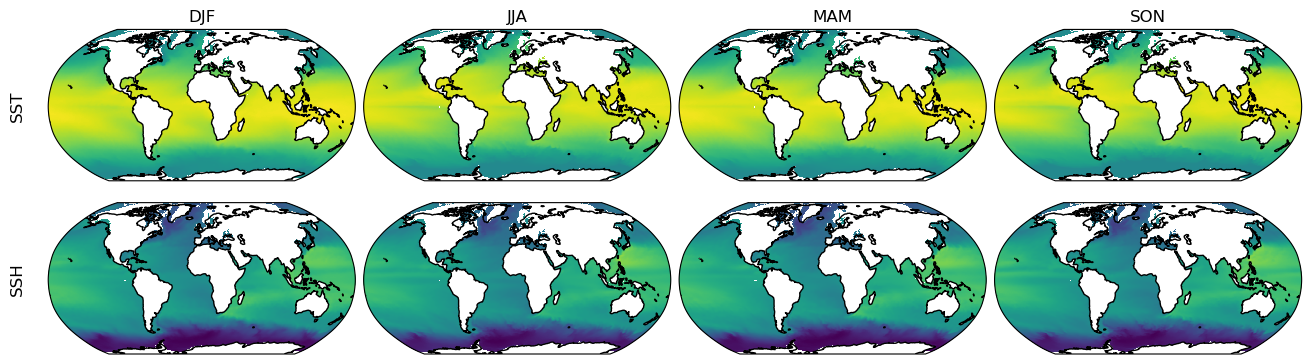

In [93]:
var_list = {
    'tos' : ['degC', 'SST', 'Sea Surface Temperature'],
    'SSH' : ['m', 'SSH', 'Sea Surface Height'],
}
nvars = len(var_list.keys())

fig, ax = plt.subplots(nvars, 4, figsize=(12, 1.8*nvars), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})
irow = 0
for var in var_list.keys():
    icol = 0
    for season in ds_seasonal_mean.season.values:
        im = ds_seasonal_mean[f'{var}'].sel(season=season).plot(ax=ax[irow,icol], transform=ccrs.PlateCarree(), cmap='viridis', add_colorbar=False)
        ax[irow,icol].coastlines()
        if irow == 0:
            ax[irow,icol].set_title(season)
        else:
            ax[irow,icol].set_title('')

        icol = icol+1

    ax[irow,0].text(-0.1, 0.5, var_list[var][1], transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontsize=12)
    irow = irow+1


#            fig.colorbar(im0, ax=[ax[indx,0],ax[indx,1]], location='bottom', pad=0.03, aspect=40, label=units)
#        fig.colorbar(im2, ax=[ax[indx,2]], location='bottom', pad=0.03, aspect=20, label=units)
#        ax[indx,0].coastlines()
#        if indx == 0:
#            ax[indx,0].set_title("ERA5")
#        else:
#            ax[indx,0].set_title("")
#        

### Time Series

In [75]:
ds_tos = ds.tos

# Calculate weights
weights1d = np.cos(np.deg2rad(ds_tos.xh))
weights2d = xr.DataArray(np.tile(weights1d.values[:,np.newaxis], (1, ds_tos.yh.size)))

# Calculate mean along longitude
#tos_mean = ds_tos.weighted(weights2d).mean(dim=['xh'])
tos_mean = ds_tos.mean(dim=['xh'])
tos_mean_clim = ds_tos.mean(dim=['time', 'xh'])
tos_mean_anom = tos_mean-tos_mean_clim

# Calculate weighted mean along latitude
weights1d = np.cos(np.deg2rad(ds_tos.yh))
tos_mean_lat = ds_tos.weighted(weights1d).mean(dim=['yh'])
print(ds_tos.xh.values)

[-286.66666667 -286.         -285.33333333 -284.66666667 -284.
 -283.33333333 -282.66666667 -282.         -281.33333333 -280.66666667
 -280.         -279.33333333 -278.66666667 -278.         -277.33333333
 -276.66666667 -276.         -275.33333333 -274.66666667 -274.
 -273.33333333 -272.66666667 -272.         -271.33333333 -270.66666667
 -270.         -269.33333333 -268.66666667 -268.         -267.33333333
 -266.66666667 -266.         -265.33333333 -264.66666667 -264.
 -263.33333333 -262.66666667 -262.         -261.33333333 -260.66666667
 -260.         -259.33333333 -258.66666667 -258.         -257.33333333
 -256.66666667 -256.         -255.33333333 -254.66666667 -254.
 -253.33333333 -252.66666667 -252.         -251.33333333 -250.66666667
 -250.         -249.33333333 -248.66666667 -248.         -247.33333333
 -246.66666667 -246.         -245.33333333 -244.66666667 -244.
 -243.33333333 -242.66666667 -242.         -241.33333333 -240.66666667
 -240.         -239.33333333 -238.66666667 -23

### Hovmueller (lat vs. time)

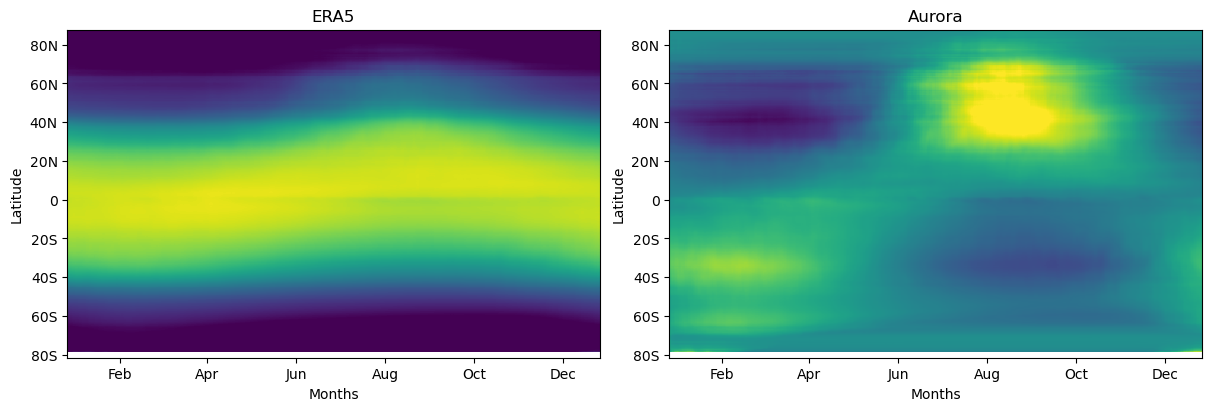

In [66]:
def format_latitude(value, tick_pos):
    if value == 0:
        return '0'
    elif value > 0:
        return f'{abs(value):.0f}N'
    else:
        return f'{abs(value):.0f}S'

fig, ax = plt.subplots(1, 2, figsize=(12,4), layout='constrained')
im0 = tos_mean.transpose().plot(ax=ax[0], vmin=0, vmax=30, cmap='viridis', add_colorbar=False)
ax[0].set_title("ERA5")
ax[0].set_xlabel('Months')
ax[0].set_ylabel('Latitude')
ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax[0].yaxis.set_major_formatter(ticker.FuncFormatter(format_latitude))

im1 = tos_mean_anom.transpose().plot(ax=ax[1], vmin=-5, vmax=5, cmap='viridis', add_colorbar=False)
ax[1].set_title("Aurora")
ax[1].set_xlabel('Months')
ax[1].set_ylabel('Latitude')
ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_latitude))

### Hovmueller (lon vs. time)

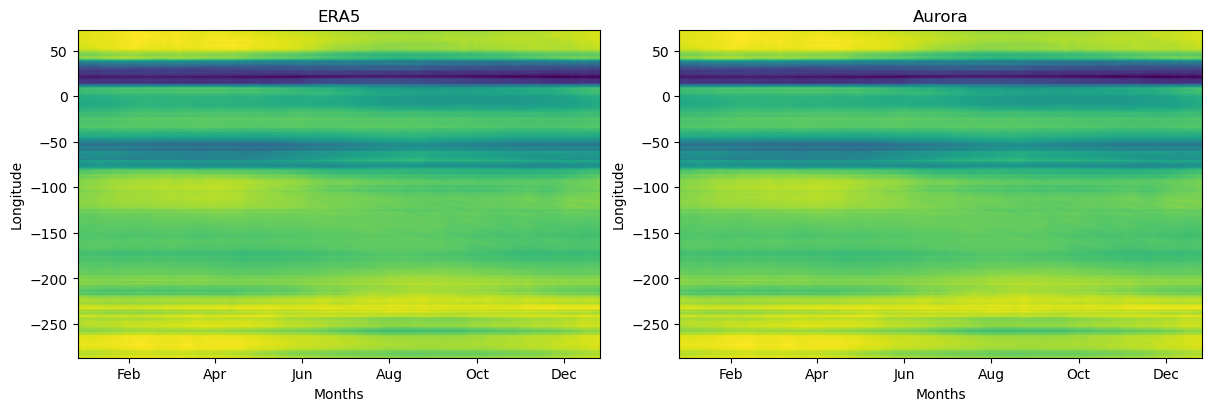

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), layout='constrained')
im0 = tos_mean_lat.transpose().plot(ax=ax[0], cmap='viridis', add_colorbar=False)
ax[0].set_title("ERA5")
ax[0].set_xlabel('Months')
ax[0].set_ylabel('Longitude')
ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

im1 = tos_mean_lat.transpose().plot(ax=ax[1], cmap='viridis', add_colorbar=False)
ax[1].set_title("Aurora")
ax[1].set_xlabel('Months')
ax[1].set_ylabel('Longitude')
ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

Faxa_prec - prec - kg m-2 s-1 - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.prec.TL319.2018.190528.nc
Faxa_lwdn - lwdn - W m-2 - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.lwdn.TL319.2018.190528.nc
Faxa_swdn -5400 - swdn - W m-2 - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.swdn.TL319.2018.190528.nc
Sa_shum - q_10 - Specific Humidity - fraction - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.q_10.TL319.2018.190528.nc
Sa_pslv - slp - Pa - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.slp.TL319.2018.190528.nc
Sa_tbot - t_10 - K - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.t_10.TL319.2018.190528.nc
Sa_u - u10 - m/s - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.u_10.TL319.2018.190528.nc
Sa_v - v10 - m/s - /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.3_noleap/JRA.v1.3.v_10.TL319.2018.190528.nc

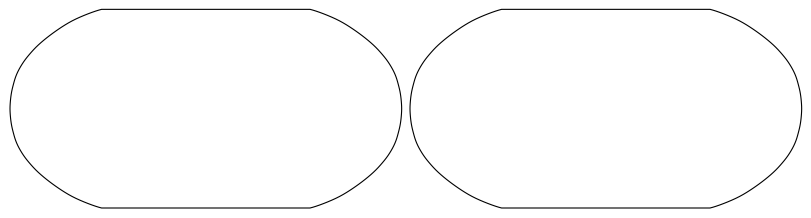

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(8,10), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})
